In [4]:
# ======================================================================
# #(1) インポート
# ======================================================================
import os
import csv
from datetime import datetime, date, timedelta
from typing import Optional, Union

import pandas as pd


# ======================================================================
# #(2) 設定
# ======================================================================
JYOUTO_DIR = os.path.join("Data", "jyouto")


# ======================================================================
# #(3) 日付・パス ユーティリティ
# ======================================================================
def _ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)

def _year_path(year: int) -> str:
    return os.path.join(JYOUTO_DIR, f"{year}.csv")

def _parse_date_to_yyyy_mm_dd(d: str) -> str:
    """
    d:
      - 'YYMMDD' (例: '250101' -> 2025-01-01)
      - 'YYYYMMDD' (例: '20250101')
      - 'YYYY-MM-DD'
    """
    d = str(d).strip()
    if len(d) == 6 and d.isdigit():
        yy = int(d[:2])
        mm = int(d[2:4])
        dd = int(d[4:6])
        yyyy = 2000 + yy
        return f"{yyyy:04d}-{mm:02d}-{dd:02d}"
    if len(d) == 8 and d.isdigit():
        yyyy = int(d[:4])
        mm = int(d[4:6])
        dd = int(d[6:8])
        return f"{yyyy:04d}-{mm:02d}-{dd:02d}"
    # ざっくりチェック
    try:
        dt = datetime.strptime(d, "%Y-%m-%d").date()
        return dt.strftime("%Y-%m-%d")
    except ValueError:
        raise ValueError(f"日付形式が不正です: {d}（YYMMDD / YYYYMMDD / YYYY-MM-DD を想定）")

def _find_sbi_trade_header_row(csv_path: str) -> tuple[int, str]:
    """
    SBI国内株式CSV内で
    1列目='約定日' かつ 2列目='口座'
    の行番号と使用encodingを返す
    """
    f, encoding = _open_csv_with_fallback(csv_path)
    with f:
        reader = csv.reader(f)
        for i, row in enumerate(reader):
            if len(row) >= 2 and row[0].strip() == "約定日" and row[1].strip() == "口座":
                return i, encoding

    raise ValueError("取引テーブルのヘッダ行（約定日, 口座）が見つかりませんでした。")

# ======================================================================
# #(3-1) CSVを安全に開く（UTF-8 → CP932 フォールバック）
# ======================================================================
def _open_csv_with_fallback(csv_path: str):
    """
    UTF-8-sig → CP932 の順でCSVを開く
    戻り値: (file_object, encoding)
    """
    try:
        f = open(csv_path, "r", encoding="utf-8-sig", newline="")
        # 1文字読んでみる（失敗検出用）
        f.read(1)
        f.seek(0)
        return f, "utf-8-sig"
    except UnicodeDecodeError:
        f = open(csv_path, "r", encoding="cp932", newline="")
        return f, "cp932"

# ======================================================================
# #(3-2) SBI系CSV：取引テーブルヘッダ行を探す（約定日, 口座）
# ======================================================================
def _find_sbi_trade_header_row(csv_path: str) -> tuple[int, str]:
    """
    先頭2列が '約定日','口座' の行を探し、(行番号, encoding) を返す
    """
    f, encoding = _open_csv_with_fallback(csv_path)
    with f:
        reader = csv.reader(f)
        for i, row in enumerate(reader):
            if len(row) >= 2 and row[0].strip() == "約定日" and row[1].strip() == "口座":
                return i, encoding
    raise ValueError("取引テーブルのヘッダ行（約定日, 口座）が見つかりませんでした。")

# ======================================================================
# #(4) 年度CSVの作成・読込・保存（フォーマット固定）
# 仕様：
#  1行目: ヘッダ  code, 1301, 1305, ...
#  2行目: name行  name,  ,    ,   ...
#  3行目以降: YYYY-MM-DD を1列目に並べ、該当があれば数値、なければ空欄
# ======================================================================
def _make_year_df(year: int) -> pd.DataFrame:
    start = date(year, 1, 1)
    end = date(year, 12, 31)

    rows = [{"code": "name"}]
    cur = start
    while cur <= end:
        rows.append({"code": cur.strftime("%Y-%m-%d")})
        cur += timedelta(days=1)

    df = pd.DataFrame(rows, columns=["code"])
    return df

def _load_or_create_year_df(year: int) -> pd.DataFrame:
    _ensure_dir(JYOUTO_DIR)
    path = _year_path(year)

    if not os.path.exists(path):
        df = _make_year_df(year)
        _save_year_df(df, year)
        return df

    # 既存読込（code列は文字、他は数値/空欄混在）
    df = pd.read_csv(path, encoding="utf-8-sig", dtype={"code": str})
    # "name" 行が無い/壊れてる場合にも最低限救う
    if df.empty or "code" not in df.columns:
        df = _make_year_df(year)
        _save_year_df(df, year)
        return df

    if df.iloc[0]["code"] != "name":
        # 先頭に name 行を挿入
        name_row = pd.DataFrame([{"code": "name"}])
        df = pd.concat([name_row, df], ignore_index=True)

    return df

def _sort_code_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = list(df.columns)
    if "code" not in cols:
        raise ValueError("CSVに 'code' 列が見つかりません。")

    other = [c for c in cols if c != "code"]

    def _sort_key(x: str):
        s = str(x).strip()
        # 数字だけなら (0, 数値) で先に
        if s.isdigit():
            return (0, int(s), s)
        # 末尾に英字付き（例: 208A）などは (1, 数字部分, 文字列) で後に
        import re
        m = re.match(r"^(\d+)([A-Za-z]+)$", s)
        if m:
            return (1, int(m.group(1)), s.upper())
        # その他の変なのは最後
        return (2, 10**18, s)

    other_sorted = sorted(other, key=_sort_key)
    return df[["code"] + other_sorted]


def _save_year_df(df: pd.DataFrame, year: int) -> None:
    path = _year_path(year)
    df = _sort_code_columns(df)

    # code列以外は「空欄 or 数値」を狙って、NaNは空欄にして書く
    df_out = df.copy()
    for c in df_out.columns:
        if c == "code":
            continue
        df_out[c] = pd.to_numeric(df_out[c], errors="coerce")

    df_out.to_csv(path, index=False, encoding="utf-8-sig", float_format="%.10g")


# ======================================================================
# #(5) 列追加・日付行セット（manual 用の共通部品）
#   - code を int 化しない（208A対応）
#   - 数字だけなら 4桁ゼロ埋め（"0" -> "0000" / "1301" -> "1301"）
# ======================================================================
def _normalize_code(code: Union[str, int]) -> str:
    s = str(code).strip()
    # 例: 208a -> 208A
    s = s.upper()
    # 数字だけなら4桁ゼロ埋め（日本株コード想定）
    if s.isdigit():
        return s.zfill(4)
    return s

def _ensure_columns_bulk(df: pd.DataFrame, codes: list[str]) -> pd.DataFrame:
    """
    断片化を避けるため、足りない列はまとめて追加する
    """
    missing = [c for c in codes if c not in df.columns]
    if not missing:
        return df

    add_df = pd.DataFrame({c: pd.NA for c in missing}, index=df.index)
    # まとめて連結（insert連発を回避）
    df = pd.concat([df, add_df], axis=1)
    return df

def _set_value(df: pd.DataFrame, yyyymmdd: str, code: Union[str, int], value: Union[str, float, int]) -> pd.DataFrame:
    d = _parse_date_to_yyyy_mm_dd(yyyymmdd)
    code_str = _normalize_code(code)

    # 対象日付の行がなければ追加（通常は不要だが保険）
    if not (df["code"] == d).any():
        df = pd.concat([df, pd.DataFrame([{"code": d}])], ignore_index=True)

    # 列がなければ追加（単発追加だが、sbi側では bulk を使うのでここは頻度低）
    if code_str not in df.columns:
        df = pd.concat([df, pd.DataFrame({code_str: pd.NA}, index=df.index)], axis=1)

    # 今回値（数値化できなければ NaN）
    new_v = pd.to_numeric(value, errors="coerce")

    # 既存値
    idx = df.index[df["code"] == d][0]
    old_v = df.at[idx, code_str]

    # 既存が空欄ならそのままセット
    if pd.isna(old_v):
        df.at[idx, code_str] = new_v
        return df

    # 既存がある場合：ユーザ確認（同日同銘柄）
    old_num = pd.to_numeric(old_v, errors="coerce")

    # 新旧どちらかが NaN なら、上書き（情報としては新しい入力を優先）
    if pd.isna(old_num) or pd.isna(new_v):
        df.at[idx, code_str] = new_v
        return df

    # 既に同じ値なら何もしない（重複投入の防止）
    if float(old_num) == float(new_v):
        return df

    while True:
        ans = input(
            f"[同日同銘柄] {d} / {code_str} に既存値={float(old_num):g} が存在します。"
            f" 今回入力={float(new_v):g}\n"
            "  A: 合算（既存+今回） / O: 上書き（今回で置換） / S: スキップ（何もしない）\n"
            "選択 (A/O/S): "
        ).strip().upper()

        if ans == "A":
            df.at[idx, code_str] = float(old_num) + float(new_v)
            return df
        if ans == "O":
            df.at[idx, code_str] = float(new_v)
            return df
        if ans == "S":
            return df

        print("入力が不正です。A / O / S のいずれかを入力してください。")

# ======================================================================
# #(6) 公開API：手入力
# ======================================================================
def manual_jyouto(code: Union[str, int], yymmdd: str, jyouto_soneki: Union[str, float, int]) -> None:
    """
    manual_jyouto("1301", "250105", 2070.0)
    manual_jyouto(1301, "2025-01-05", "2070")
    """
    d = _parse_date_to_yyyy_mm_dd(yymmdd)
    year = int(d[:4])

    df = _load_or_create_year_df(year)
    df = _set_value(df, d, code, jyouto_soneki)
    _save_year_df(df, year)


# ======================================================================
# #(7) 公開API：SBI（列追加をまとめて行い、断片化を抑制）
# ======================================================================
def sbi_jyouto(csv_path: str = os.path.join("Data", "Input_own", "sbi_domestic.csv")) -> None:
    header_row, encoding = _find_sbi_trade_header_row(csv_path)

    df = pd.read_csv(
        csv_path,
        encoding=encoding,
        skiprows=header_row,
        dtype=str
    )

    required = ["約定日", "銘柄名", "実現損益(税引前・円)"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"SBI CSVに必要列 '{c}' が見つかりません。")

    work = df[["約定日", "銘柄名", "実現損益(税引前・円)"]].copy()
    work = work[work["約定日"].notna() & work["約定日"].str.strip().ne("")]

    # 日付整形
    work["約定日"] = work["約定日"].str.strip().str.replace("/", "-", regex=False)

    def _norm_ymd(s: str) -> str:
        y, m, d = str(s).split("-")
        return f"{int(y):04d}-{int(m):02d}-{int(d):02d}"

    work["約定日"] = work["約定日"].apply(_norm_ymd)

    # code抽出（末尾トークンを優先、正規化）
    import re
    def _extract_code(meigara: str) -> str:
        s = str(meigara).strip()
        last = s.split()[-1] if s else ""
        if re.fullmatch(r"[0-9A-Za-z]{3,5}", last):
            return _normalize_code(last)
        m = re.search(r"([0-9A-Za-z]{3,5})\s*$", s)
        if m:
            return _normalize_code(m.group(1))
        raise ValueError(f"銘柄コード抽出失敗: {meigara}")

    work["code"] = work["銘柄名"].apply(_extract_code)

    # 損益数値化
    pnl = (
        work["実現損益(税引前・円)"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    work["pnl"] = pd.to_numeric(pnl, errors="coerce")
    work = work[work["pnl"].notna()]

    # CSV内同日同銘柄は合算（質問を減らす）
    agg = work.groupby(["約定日", "code"], as_index=False)["pnl"].sum()
    agg["year"] = agg["約定日"].str.slice(0, 4).astype(int)

    for year, sub in agg.groupby("year"):
        year = int(year)
        ydf = _load_or_create_year_df(year)

        # ★ここで必要列をまとめて追加（断片化対策）
        needed_codes = sorted(sub["code"].unique().tolist())
        ydf = _ensure_columns_bulk(ydf, needed_codes)

        # ★断片化が残っている場合の保険（コピーでデフラグ）
        ydf = ydf.copy()

        sub2 = sub.sort_values(["約定日", "code"])
        for _, r in sub2.iterrows():
            ydf = _set_value(ydf, r["約定日"], r["code"], r["pnl"])

        _save_year_df(ydf, year)

def rakuten_jyouto(csv_path: str) -> None:
    """
    想定：楽天証券の譲渡益CSVを読み、Data/jyouto/YYYY.csv に反映する
    現時点：何もしない（プレースホルダ）
    """
    # TODO: 仕様確定後に実装
    return

# ======================================================================
# #(7-1) 公開API：SBI（外国株式）
# ======================================================================
def sbi_jyouto1(csv_path: str = os.path.join("Data", "Input_own", "sbi_foreign.csv")) -> None:
    """
    SBI証券（外国株式）の譲渡益履歴CSVを読み、
    Data/jyouto/YYYY.csv に反映する。

    - ヘッダ検出：先頭2列が「約定日」「口座」
    - 銘柄キー：『銘柄名/ティッカー』の末尾トークン（例："... IYR" -> "IYR"）
    - 損益：実現損益(税引前・円)
    - CSV内同日同銘柄は合算
    """
    header_row, encoding = _find_sbi_trade_header_row(csv_path)

    df = pd.read_csv(
        csv_path,
        encoding=encoding,
        skiprows=header_row,
        dtype=str
    )

    required = ["約定日", "銘柄名/ティッカー", "実現損益(税引前・円)"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"SBI foreign CSVに必要列 '{c}' が見つかりません。")

    work = df[["約定日", "銘柄名/ティッカー", "実現損益(税引前・円)"]].copy()
    work = work[work["約定日"].notna() & work["約定日"].str.strip().ne("")]

    # 日付整形
    work["約定日"] = work["約定日"].str.strip().str.replace("/", "-", regex=False)

    def _norm_ymd(s: str) -> str:
        y, m, d = str(s).split("-")
        return f"{int(y):04d}-{int(m):02d}-{int(d):02d}"

    work["約定日"] = work["約定日"].apply(_norm_ymd)

    # 銘柄キー（ティッカー）
    def _extract_ticker(s: str) -> str:
        t = str(s).strip()
        last = t.split()[-1] if t else ""
        # ティッカーは英数字（長いのもあるが、ここは広めに許容）
        if last and all(ch.isalnum() for ch in last):
            return last.upper()
        # 保険：末尾の英数字塊
        import re
        m = re.search(r"([A-Za-z0-9]+)\s*$", t)
        if m:
            return m.group(1).upper()
        raise ValueError(f"ティッカー抽出失敗: {s}")

    work["code"] = work["銘柄名/ティッカー"].apply(_extract_ticker)

    # 損益数値化
    pnl = (
        work["実現損益(税引前・円)"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    work["pnl"] = pd.to_numeric(pnl, errors="coerce")
    work = work[work["pnl"].notna()]

    # 合算
    agg = work.groupby(["約定日", "code"], as_index=False)["pnl"].sum()
    agg["year"] = agg["約定日"].str.slice(0, 4).astype(int)

    for year, sub in agg.groupby("year"):
        year = int(year)
        ydf = _load_or_create_year_df(year)

        needed_codes = sorted(sub["code"].unique().tolist())
        ydf = _ensure_columns_bulk(ydf, needed_codes)
        ydf = ydf.copy()

        for _, r in sub.sort_values(["約定日", "code"]).iterrows():
            ydf = _set_value(ydf, r["約定日"], r["code"], r["pnl"])

        _save_year_df(ydf, year)

# ======================================================================
# #(7-2) 公開API：SBI（投資信託）
# ======================================================================
def sbi_jyouto2(csv_path: str = os.path.join("Data", "Input_own", "sbi_fund.csv")) -> None:
    """
    SBI証券（投資信託）の譲渡益履歴CSVを読み、
    Data/jyouto/YYYY.csv に反映する。

    - ヘッダ検出：先頭2列が「約定日」「口座」
    - 銘柄キー：『ファンド名』をそのまま列名として使う（文字列）
    - 損益：実現損益(税引前・円)
    - CSV内同日同銘柄は合算
    """
    header_row, encoding = _find_sbi_trade_header_row(csv_path)

    df = pd.read_csv(
        csv_path,
        encoding=encoding,
        skiprows=header_row,
        dtype=str
    )

    required = ["約定日", "ファンド名", "実現損益(税引前・円)"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"SBI fund CSVに必要列 '{c}' が見つかりません。")

    work = df[["約定日", "ファンド名", "実現損益(税引前・円)"]].copy()
    work = work[work["約定日"].notna() & work["約定日"].str.strip().ne("")]

    # 日付整形
    work["約定日"] = work["約定日"].str.strip().str.replace("/", "-", regex=False)

    def _norm_ymd(s: str) -> str:
        y, m, d = str(s).split("-")
        return f"{int(y):04d}-{int(m):02d}-{int(d):02d}"

    work["約定日"] = work["約定日"].apply(_norm_ymd)

    # ファンド名を列キーとして使う（そのまま、ただし両端空白は除去）
    work["code"] = work["ファンド名"].astype(str).str.strip()

    # 損益数値化
    pnl = (
        work["実現損益(税引前・円)"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    work["pnl"] = pd.to_numeric(pnl, errors="coerce")
    work = work[work["pnl"].notna()]

    # 合算
    agg = work.groupby(["約定日", "code"], as_index=False)["pnl"].sum()
    agg["year"] = agg["約定日"].str.slice(0, 4).astype(int)

    for year, sub in agg.groupby("year"):
        year = int(year)
        ydf = _load_or_create_year_df(year)

        needed_codes = sorted(sub["code"].unique().tolist())
        ydf = _ensure_columns_bulk(ydf, needed_codes)
        ydf = ydf.copy()

        for _, r in sub.sort_values(["約定日", "code"]).iterrows():
            ydf = _set_value(ydf, r["約定日"], r["code"], r["pnl"])

        _save_year_df(ydf, year)

# ======================================================================
# #(7-3) 公開API：楽天証券（国内株式想定の譲渡益CSV）
# ======================================================================
def rakuten_jyouto(csv_path: str = os.path.join("Data", "Input_own", "rakuten_jyouto.csv")) -> None:
    """
    楽天証券の譲渡益CSVを読み、Data/jyouto/YYYY.csv に反映する。

    仕様：
      - 約定日：'約定日'
      - 銘柄コード：'銘柄コード'（4桁想定、_normalize_codeでゼロ埋め）
      - 損益：'実現損益[円]'
      - 同日同銘柄は合算してから反映
      - 既存Data/jyouto側に値がある場合は _set_value の質問ロジックに従う
    """
    # 楽天は基本UTF-8が多いが、念のためフォールバック
    f, encoding = _open_csv_with_fallback(csv_path)
    f.close()

    df = pd.read_csv(csv_path, encoding=encoding, dtype=str)

    required = ["約定日", "銘柄コード", "実現損益[円]"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"楽天CSVに必要列 '{c}' が見つかりません。見つかった列: {list(df.columns)}")

    work = df[["約定日", "銘柄コード", "実現損益[円]"]].copy()
    work = work[work["約定日"].notna() & work["約定日"].str.strip().ne("")]

    # 日付整形
    work["約定日"] = work["約定日"].astype(str).str.strip().str.replace("/", "-", regex=False)

    def _norm_ymd(s: str) -> str:
        y, m, d = str(s).split("-")
        return f"{int(y):04d}-{int(m):02d}-{int(d):02d}"

    work["約定日"] = work["約定日"].apply(_norm_ymd)

    # code（4桁ゼロ埋め）
    work["code"] = work["銘柄コード"].apply(_normalize_code)

    # 損益（カンマ除去 → 数値）
    pnl = (
        work["実現損益[円]"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    work["pnl"] = pd.to_numeric(pnl, errors="coerce")
    work = work[work["pnl"].notna()]

    # CSV内同日同銘柄は合算
    agg = work.groupby(["約定日", "code"], as_index=False)["pnl"].sum()
    agg["year"] = agg["約定日"].str.slice(0, 4).astype(int)

    for year, sub in agg.groupby("year"):
        year = int(year)
        ydf = _load_or_create_year_df(year)

        # 必要列をまとめて追加（断片化対策）
        needed_codes = sorted(sub["code"].unique().tolist())
        ydf = _ensure_columns_bulk(ydf, needed_codes)
        ydf = ydf.copy()

        for _, r in sub.sort_values(["約定日", "code"]).iterrows():
            ydf = _set_value(ydf, r["約定日"], r["code"], r["pnl"])

        _save_year_df(ydf, year)


# ======================================================================
# #(8) 公開API：ファイル整理（列を昇順に並べ替え）
# ======================================================================
def tidy_jyouto(year: int) -> None:
    """
    列順を code, 1301, 1305, ... のように昇順へ整理して保存し直す
    """
    df = _load_or_create_year_df(year)
    _save_year_df(df, year)


In [5]:
# 2025年の 1301 に 2025-01-05 の譲渡益を入れる（該当年の Data/jyouto/2025.csv が作られる）
# manual_jyouto("0000", "250105", 20.0)

# 列順整理だけしたい場合
# tidy_jyouto(2025)

# SBI
sbi_jyouto("Data/Input_own/sbi_domestic.csv")
sbi_jyouto1("Data/Input_own/sbi_foreign.csv")
sbi_jyouto2("Data/Input_own/sbi_fund.csv")
rakuten_jyouto("Data/Input_own/rakuten_jyouto.csv")

In [6]:
# ======================================================================
# #(9-0) サマリー用 定数定義（依存関係を明示）
# ======================================================================
IDMAP_CSV = os.path.join("Data", "01_IDmap.csv")
JYOUTO_DIR = os.path.join("Data", "jyouto")


# ======================================================================
# #(9-1) IDmap 読み込み（code -> name）
# ======================================================================
def _load_idmap_code_name() -> dict[str, str]:
    """
    Data/01_IDmap.csv から code -> name の辞書を作る
    01_IDmapに無い銘柄は空欄のまま（=何もしない）でOK
    """
    if not os.path.exists(IDMAP_CSV):
        raise FileNotFoundError(f"IDMAP_CSV が見つかりません: {IDMAP_CSV}")

    df = pd.read_csv(IDMAP_CSV, encoding="utf-8-sig", dtype=str)

    if "code" not in df.columns or "name" not in df.columns:
        raise ValueError("01_IDmap.csv に 'code' または 'name' 列がありません。")

    mp: dict[str, str] = {}
    for _, r in df.iterrows():
        c = str(r["code"]).strip()
        n = str(r["name"]).strip()
        if not c or c.lower() == "nan":
            continue
        if not n or n.lower() == "nan":
            continue
        mp[c] = n

    return mp


# ======================================================================
# #(9-2) Data/jyouto/YYYY.csv の一覧取得
# ======================================================================
import glob

def _list_jyouto_year_files() -> list[tuple[int, str]]:
    """
    Data/jyouto 配下の YYYY.csv を列挙
    """
    files = glob.glob(os.path.join(JYOUTO_DIR, "*.csv"))
    out = []
    for p in files:
        base = os.path.basename(p)
        name, ext = os.path.splitext(base)
        if ext.lower() != ".csv":
            continue
        if name.isdigit() and len(name) == 4:
            out.append((int(name), p))
    out.sort(key=lambda x: x[0])
    return out


# ======================================================================
# #(9-3) サマリー用：銘柄キー並び替え
# ======================================================================
def _sort_keys_for_summary(cols: list[str]) -> list[str]:
    """
    数字コード → 英字付き → その他文字列 の順で並び替え
    """
    def _sort_key(x: str):
        s = str(x).strip()
        if s.isdigit():
            return (0, int(s), s)
        import re
        m = re.match(r"^(\d+)([A-Za-z]+)$", s)
        if m:
            return (1, int(m.group(1)), s.upper())
        return (2, 10**18, s)
    return sorted(cols, key=_sort_key)


# ======================================================================
# #(9-4) 譲渡益サマリー作成
# ======================================================================
def build_jyouto_summary(
    output_path: str = os.path.join(JYOUTO_DIR, "summary.csv"),
    include_years: Optional[list[int]] = None
) -> None:
    """
    Data/jyouto/YYYY.csv を集計して summary.csv を出力する

    出力仕様：
      列:
        1列目 year
        2列目 total（合計損益）
        3列目以降 銘柄コード / ティッカー / ファンド名

      行:
        1行目 year='name'   : 01_IDmap.csv の name を反映（無いものは空欄）
        2行目 year='total'  : 全期間合計（2列目も全期間合計）
        3行目以降           : 年度別集計（2列目は年度合計）
    """
    # --- IDmap 読み込み ---
    idmap = _load_idmap_code_name()

    # --- 年度ファイル列挙 ---
    year_files = _list_jyouto_year_files()
    if include_years is not None:
        include_set = set(include_years)
        year_files = [(y, p) for (y, p) in year_files if y in include_set]

    if not year_files:
        raise ValueError("Data/jyouto に年度ファイル（YYYY.csv）が見つかりません。")

    year_to_series: dict[int, pd.Series] = {}
    all_codes: set[str] = set()

    # --- 各年度の集計 ---
    for year, path in year_files:
        df = pd.read_csv(path, encoding="utf-8-sig", dtype={"code": str})
        if "code" not in df.columns:
            continue

        cols = [c for c in df.columns if c != "code"]
        all_codes.update(cols)

        df_num = df[df["code"] != "name"].copy()
        for c in cols:
            df_num[c] = pd.to_numeric(df_num[c], errors="coerce")

        s_sum = df_num[cols].sum(axis=0, skipna=True)
        year_to_series[year] = s_sum

    # --- 列順確定 ---
    code_cols = _sort_keys_for_summary(list(all_codes))
    out_cols = ["year", "total"] + code_cols

    # ==========================================================
    # 1行目：name（01_IDmap.csv 参照）
    # ==========================================================
    name_values = {c: idmap.get(c, "") for c in code_cols}
    row_name = {"year": "name", "total": ""} | name_values

    # ==========================================================
    # 2行目：total（全期間合計）
    # ==========================================================
    total_series = pd.Series({c: 0.0 for c in code_cols}, dtype="float64")
    for s in year_to_series.values():
        for c in s.index:
            if c in total_series.index and pd.notna(s[c]):
                total_series[c] += float(s[c])

    grand_total = float(total_series.sum(skipna=True))
    row_total = {"year": "total", "total": grand_total}
    for c in code_cols:
        row_total[c] = float(total_series.get(c, 0.0))

    # ==========================================================
    # 年度別行
    # ==========================================================
    year_rows = []
    for y in sorted(year_to_series.keys()):
        s = year_to_series[y]
        row = {"year": y}
        row["total"] = float(s.sum(skipna=True)) if not s.empty else 0.0
        for c in code_cols:
            row[c] = float(s.get(c, 0.0)) if c in s.index and pd.notna(s.get(c)) else 0.0
        year_rows.append(row)

    # --- 出力 ---
    out_df = pd.DataFrame([row_name, row_total] + year_rows, columns=out_cols)
    out_df.to_csv(output_path, index=False, encoding="utf-8-sig", float_format="%.10g")

# 全年度分を集計して Data/jyouto/summary.csv を出力
build_jyouto_summary()

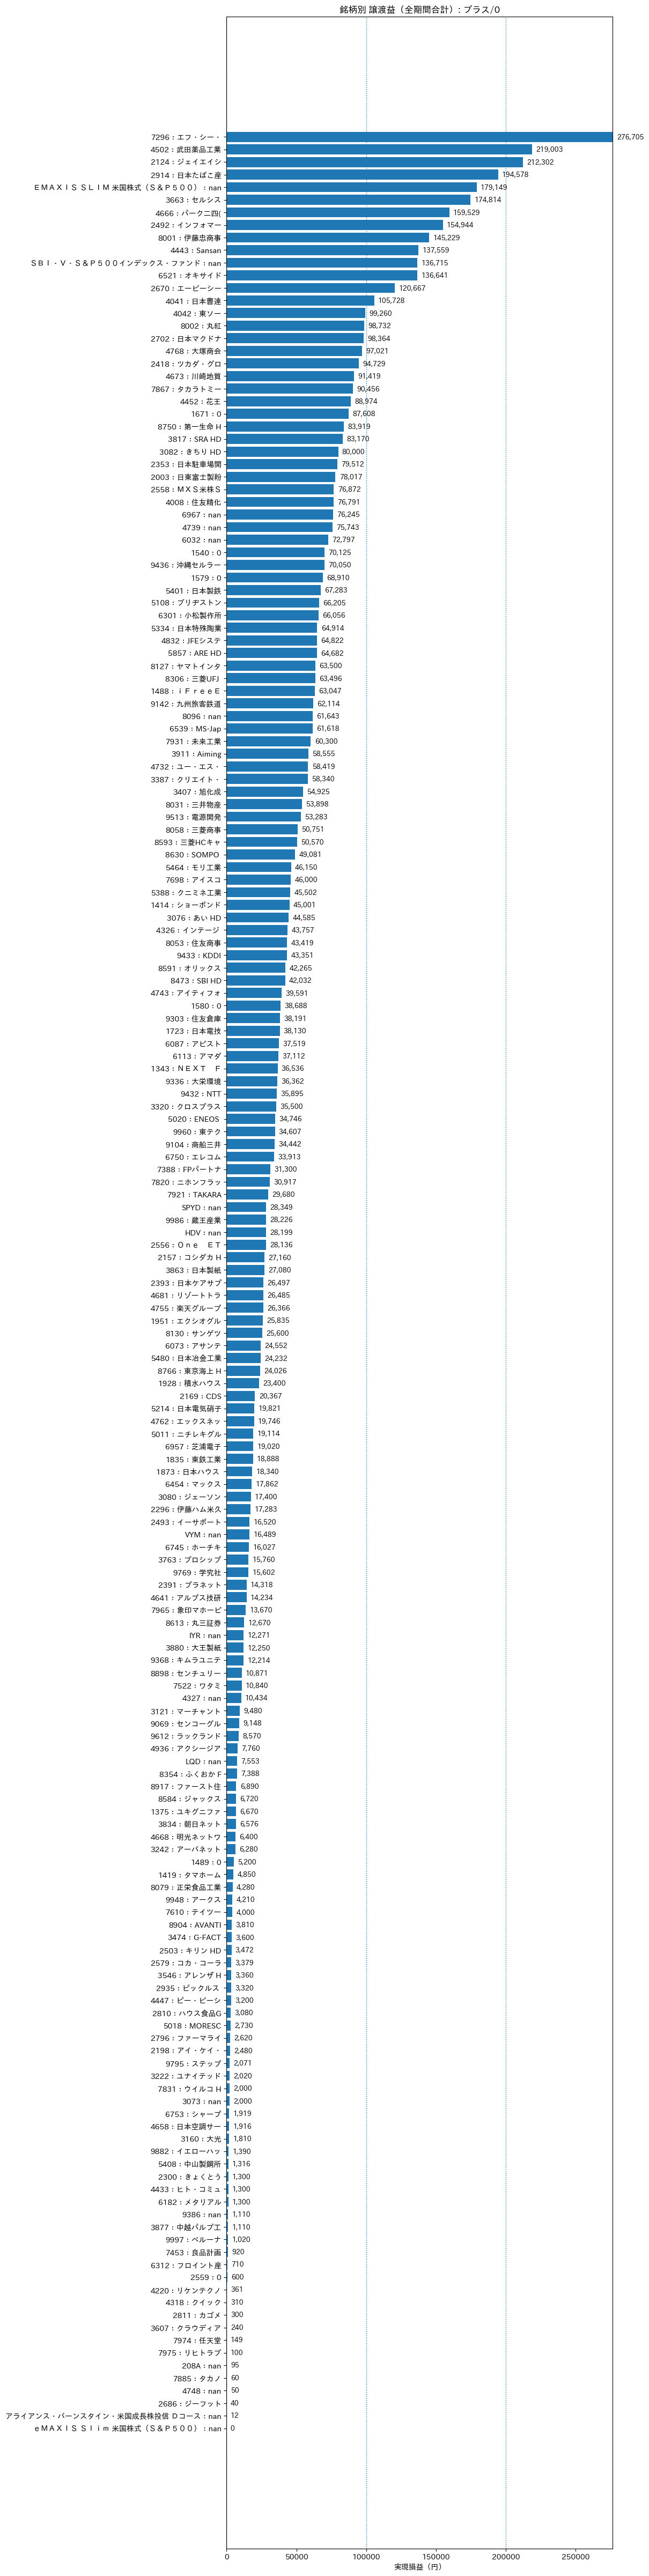

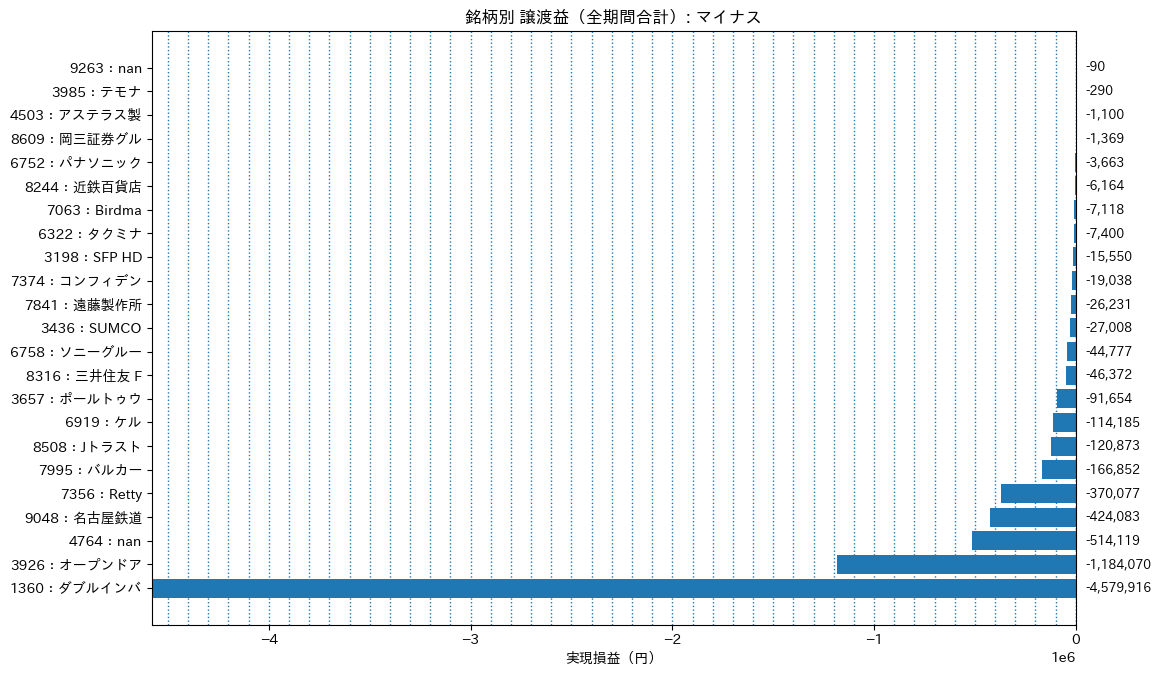

In [7]:
# ============================================================
# 譲渡益サマリー（プラス/マイナス分離・横棒グラフ）
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import os
import numpy as np

SUMMARY_CSV = os.path.join("Data", "jyouto", "summary.csv")

# ------------------------------------------------------------
# データ読み込み
# ------------------------------------------------------------
df = pd.read_csv(SUMMARY_CSV, encoding="utf-8-sig", dtype=str)
df.columns = [str(c).replace("\ufeff","").replace("\u3000"," ").strip() for c in df.columns]
df["year"] = df["year"].astype(str).str.replace("\ufeff","").str.strip()

df_name = df[df["year"] == "name"]
df_total = df[df["year"] == "total"]
if df_total.empty:
    raise ValueError("summary.csv に year='total' 行が見つかりません。")

code_cols = [c for c in df.columns if c not in ("year", "total")]

def _short_name6(s: str) -> str:
    s = str(s).strip()
    return s[:6] if s else ""

rows = []
for code in code_cols:
    val = pd.to_numeric(df_total.iloc[0][code], errors="coerce")
    if pd.isna(val):
        continue

    name = ""
    if not df_name.empty and code in df_name.columns:
        name = str(df_name.iloc[0][code]).strip()

    code_str = str(code).strip()
    nm6 = _short_name6(name)
    label = f"{code_str}：{nm6}" if nm6 else f"{code_str}"

    rows.append({"label": label, "total": float(val)})

plot_df = pd.DataFrame(rows)

pos_df = plot_df[plot_df["total"] >= 0].sort_values("total", ascending=True).reset_index(drop=True)  # 小→大
neg_df = plot_df[plot_df["total"] < 0].sort_values("total", ascending=True).reset_index(drop=True)   # よりマイナス→0

# ------------------------------------------------------------
# 描画関数
# ------------------------------------------------------------
def _draw_barh(ax, data: pd.DataFrame, title: str, xlim: tuple[float, float], step: int = 100_000, value_label_mode: str = "auto"):
    ax.barh(data["label"], data["total"])
    ax.set_title(title)
    ax.set_xlabel("実現損益（円）")
    ax.set_xlim(*xlim)

    # 縦点線（10万刻み） + 0線
    start = int(np.floor(xlim[0] / step) * step)
    end = int(np.ceil(xlim[1] / step) * step)
    for x in range(start, end + step, step):
        ax.axvline(x, linestyle=":", linewidth=1)
    ax.axvline(0, linestyle=":", linewidth=1)

    # 値ラベル（整数カンマ）
    width = (xlim[1] - xlim[0]) if xlim[1] != xlim[0] else 1.0
    offset = width * 0.01

    # value_label_mode:
    #  - "auto" : v>=0 は右、v<0 は左
    #  - "right" : すべて棒の右側（+方向側）に寄せる（マイナス図向け）
    for y, v in enumerate(data["total"].values):
        s = f"{int(round(v)):,}"

        if value_label_mode == "right":
            # ★右側固定：0側（右端）に寄せて表示
            x = 0 + offset
            ax.text(x, y, s, va="center", ha="left", fontsize=9)
        else:
            # 従来：符号で左右
            if v >= 0:
                ax.text(v + offset, y, s, va="center", ha="left", fontsize=9)
            else:
                ax.text(v - offset, y, s, va="center", ha="right", fontsize=9)

    # 左の余白を詰める（ラベル長に応じて）
    max_len = int(data["label"].astype(str).map(len).max()) if len(data) else 10
    left = 0.18 + min(0.20, max(0.0, (max_len - 8) * 0.01))
    left = min(0.38, max(0.18, left))
    ax.figure.subplots_adjust(left=left, right=0.98, top=0.92, bottom=0.06)

# ------------------------------------------------------------
# 2枚に分けて表示
# ------------------------------------------------------------
# 1) プラス（0含む）
if len(pos_df) > 0:
    xmax = float(pos_df["total"].max())
    fig_h = max(6, 0.30 * len(pos_df))
    fig, ax = plt.subplots(figsize=(12, fig_h))
    _draw_barh(ax, pos_df, "銘柄別 譲渡益（全期間合計）: プラス/0", (0, xmax))
    plt.show()
else:
    print("プラス（0含む）の銘柄がありません。")

# 2) マイナス
if len(neg_df) > 0:
    xmin = float(neg_df["total"].min())
    fig_h = max(6, 0.30 * len(neg_df))
    fig, ax = plt.subplots(figsize=(12, fig_h))
    _draw_barh(ax, neg_df, "銘柄別 譲渡益（全期間合計）: マイナス", (xmin, 0), value_label_mode="right")
    plt.show()
else:
    print("マイナスの銘柄がありません。")
